<a href="https://colab.research.google.com/github/YakovDeLeon/ML_Course_PT/blob/main/Lecture5_IntroDL_CV/PT_DL_HT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание

В этом домашнем задании вы обучите полносвязную нейронную сеть для решения задачи классификации на датасете CIFAR-10.

Это домашнее задание оформлено в не совсем традиционном формате. Не хочется заставлять вас копировать код. Вы будете менять уже существующую архитектуру, а затем отвечать на вопросы.

## Задание 1

Запустите данный изначально код и замерьте качество (accuracy) на тестовых данных.

48%

## Задание 2

Добавьте еще один полносвязный слой (перед выходным) из 100 нейронов + функцию активации ReLU и запустите обучение. Замерьте accuracy на тесте.

51,53%

## Задание 3

Теперь обучите полносвязную сеть с несколькими линейными слоями с числом нейронов: 1024, 512, 256, 128, 64 соответственно + функцией ReLU на выходе из каждого внутреннего слоя. Замерьте accuracy.

53.8%

## Задание 4

К архитектуре из предыдущего задания добавьте Dropout(0.2) перед слоями из 1024 и 256 нейронов. Увеличилась ли accuracy по сравнению с предыдущим заданием?

*P.S. Спросите у ChatGPT, что такое Dropout? Зачем он нужен?*

53.21 %

Dropout с заданной вероятностью (например, 0.2) зануляет выходы случайных нейронов. Они просто «выключаются» на один шаг.
Не рекомендуется ставить dropout перед первым слоем, так как на картинке уже сотрётся какая-то часть пикселей и нейронке будет сложнее обучаться.

Если dropout оставить только перед слоем в 256 нейронов, то точность становится 53,2%

## Задание 5

Уберите Dropout, но добавьте BatchNorm перед входом в те же линейные слои. Увеличилась ли accuracy по сравнению с заданием 3?

*P.S. Спросите у ChatGPT, что такое BatchNorm? Зачем он нужен?*

Accuracy подросло до 56,15%.

BatchNorm нормализует выходные данные слоя. Без BatchNorm веса в глубоких слоях постоянно «гоняются» за изменениями в предыдущих слоях (эффект домино). BatchNorm стабилизирует этот процесс, с ним можно ставить гораздо более высокий Learning Rate.

## Задание 6

Теперь пробуйте что угодно:
* разное число линейных слоев
* разные функции активации (вместо ReLU)
* комбинации Dropout / BatchNorm
* наконец, попробуйте написать сверточную нейронную сеть! :)

Цель - добиться наибольшей accuracy на тесте.

Добавил свёрточную нейрнонную сеть. С изначальным количествои каналов на свёрткх 5 10 20, accuracy был окол 53%, что даже хуже чему у обычной нейронной модели. Затем увеличение количества каналов дало прирост до 76% точности. Также прочитал, что если к исходной картинкам применить поворты и затирания пикселей, то это должно улучшить модель, но у меня наоборот деградация произошла, на обычной нейронной модели качество упало до 50%, а на нейронной до 70%, так что вернул назад. Увеличил число эпох до 20, качество модели выросло до 78.97%. Попробовал поменять функции активации на Mish в свёртках и GeLU в нейронной модели, в итоге где-то на 15-й эпохе модель уже окончательно обучилась, и далее ошибки минимальные. Само качество модели выросло до 79.79%. Можно ещё количество свёрточных каналов в 2 раза покрутить, но у меня перестало подключаться к гпу:)

In [67]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import random
import numpy as np

def seed():
  np.random.seed(0)
  random.seed(0)
  torch.manual_seed(0)
  torch.cuda.manual_seed(0)
  torch.cuda.manual_seed_all(0)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False

seed()

In [68]:
# Check Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define Hyper-parameters
input_size = 3072
num_classes = 10
num_epochs = 10
batch_size = 32
learning_rate = 0.001

In [69]:
# MNIST dataset
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

train_dataset = torchvision.datasets.CIFAR10(root='../../data',
                                           train=True,
                                           transform=transform,
                                           download=True)

test_dataset = torchvision.datasets.CIFAR10(root='../../data',
                                          train=False,
                                          transform=transform)

In [70]:
# Data loader
seed()
train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=batch_size,
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=test_dataset,
                                          batch_size=batch_size,
                                          shuffle=False)

In [71]:
# Fully connected neural network
class NeuralNet(nn.Module):
    def __init__(self, input_size, num_classes):
        super(NeuralNet, self).__init__()
        seed()
        self.fc1 = nn.Linear(input_size, 1024)
        self.bn1 = nn.BatchNorm1d(1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 256)
        self.bn3 = nn.BatchNorm1d(256)
        self.fc4 = nn.Linear(256, 128)
        self.fc5 = nn.Linear(128, 64)
        self.fc6 = nn.Linear(64, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
#        self.apply(self._init_weights)

    def _init_weights(self, module): # метод для различных "умных" инициализаций весов
        seed()
        if isinstance(module, nn.Linear):
            module.weight.data.normal_(mean=0.0, std=0.15)
            if module.bias is not None:
                module.bias.data.zero_()

    def forward(self, x):
        out = self.fc1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.relu(out)
        out = self.fc3(out)
        out = self.bn3(out)
        out = self.relu(out)
        out = self.fc4(out)
        out = self.relu(out)
        out = self.fc5(out)
        out = self.relu(out)
        out = self.fc6(out)
        return out

model = NeuralNet(input_size, num_classes).to(device)

In [72]:
model

NeuralNet(
  (fc1): Linear(in_features=3072, out_features=1024, bias=True)
  (bn1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=1024, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=256, bias=True)
  (bn3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc4): Linear(in_features=256, out_features=128, bias=True)
  (fc5): Linear(in_features=128, out_features=64, bias=True)
  (fc6): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
)

In [73]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [74]:
seed()

loss_log = []

# Train the model
total_step = len(train_loader)
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        # Move tensors to the configured device
        images = images.reshape(-1, 32*32*3).to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backprpagation and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i+1) % 100 == 0:
            print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}'
                   .format(epoch+1, num_epochs, i+1, total_step, loss.item()))
            loss_log.append(loss.data.cpu().numpy())

Epoch [1/10], Step [100/1563], Loss: 2.3079
Epoch [1/10], Step [200/1563], Loss: 1.9189
Epoch [1/10], Step [300/1563], Loss: 1.7769
Epoch [1/10], Step [400/1563], Loss: 1.8055
Epoch [1/10], Step [500/1563], Loss: 1.9277
Epoch [1/10], Step [600/1563], Loss: 1.7324
Epoch [1/10], Step [700/1563], Loss: 1.5938
Epoch [1/10], Step [800/1563], Loss: 1.8451
Epoch [1/10], Step [900/1563], Loss: 1.6116
Epoch [1/10], Step [1000/1563], Loss: 1.4710
Epoch [1/10], Step [1100/1563], Loss: 1.8525
Epoch [1/10], Step [1200/1563], Loss: 1.6933
Epoch [1/10], Step [1300/1563], Loss: 1.5939
Epoch [1/10], Step [1400/1563], Loss: 1.6278
Epoch [1/10], Step [1500/1563], Loss: 1.4644
Epoch [2/10], Step [100/1563], Loss: 1.5854
Epoch [2/10], Step [200/1563], Loss: 1.3350
Epoch [2/10], Step [300/1563], Loss: 1.4884
Epoch [2/10], Step [400/1563], Loss: 1.7551
Epoch [2/10], Step [500/1563], Loss: 1.4221
Epoch [2/10], Step [600/1563], Loss: 1.6957
Epoch [2/10], Step [700/1563], Loss: 1.3838
Epoch [2/10], Step [800/15

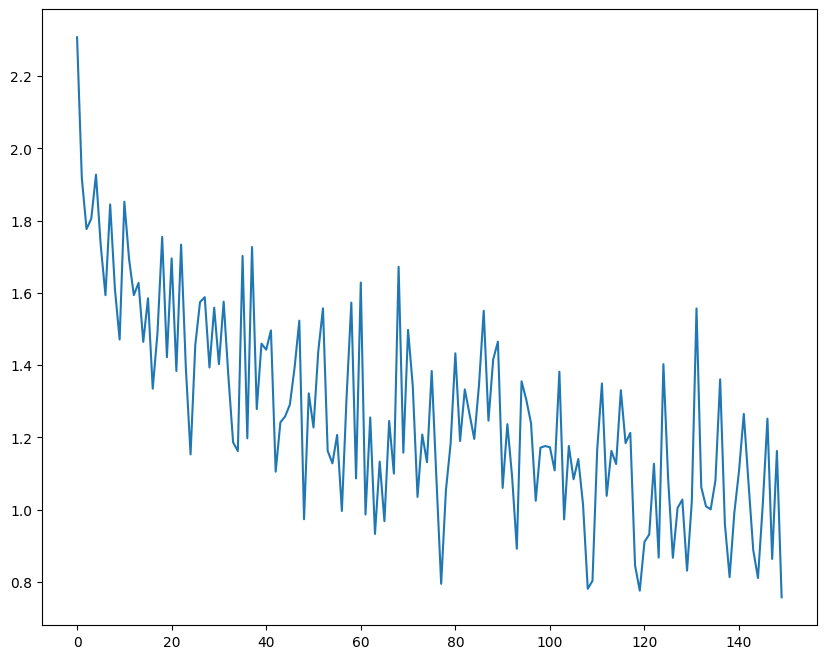

In [75]:
from matplotlib import pyplot as plt

plt.figure(figsize=(10,8))
plt.plot(loss_log)

In [76]:
seed()

# Test the model
# In the test phase, don't need to compute gradients (for memory efficiency)
with torch.no_grad():
    model.eval()
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.reshape(-1, 32*32*3).to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print('Accuracy of the network on the test images: {} %'.format(100 * correct / total))

# Save the model checkpoint
torch.save(model.state_dict(), 'model.ckpt')

Accuracy of the network on the test images: 56.15 %


In [1]:
class ConvNet(nn.Module):

    def __init__(self, image_channels=3):
        super().__init__()

        self.encoder = nn.Sequential(  # 32 x 32 x 3
            nn.Conv2d(in_channels=image_channels, out_channels=32,
                      kernel_size=3, padding=1),  # 32 x 32 x 32
            nn.BatchNorm2d(64),
            nn.Mish(),
            nn.MaxPool2d(2),  # 16 x 16 x 64

            nn.Conv2d(in_channels=64, out_channels=128,
                      kernel_size=3, padding=1),  # 16 x 16 x 64
            nn.BatchNorm2d(128),
            nn.Mish(),
            nn.MaxPool2d(2),  # 8 x 8 x 10

            nn.Conv2d(in_channels=128, out_channels=256,
                      kernel_size=3, padding=1),  # 8 x 8 x 128
            nn.BatchNorm2d(256),
            nn.Mish(),
            nn.MaxPool2d(2)  # 4 x 4 x 256 = 2048
        )

        self.head = nn.Sequential(
            nn.Linear(in_features=4096, out_features=1024),
            nn.GELU(),
            nn.Linear(in_features=1024, out_features=512),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(in_features=512, out_features=10)
        )

    def forward(self, x):

        # x: B x 1 x 28 x 28
        out = self.encoder(x)   # out: B x 392
        out = nn.Flatten()(out) # out: B x 180
        out = self.head(out)    # out: B x 10
        return out

    def get_embedding(self, x):
        out = self.encoder(x)
        return nn.Flatten()(out)

NameError: name 'nn' is not defined

In [95]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

model_cnn = ConvNet().to(device)
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(model_cnn.parameters(), lr=0.01, momentum=0)

In [96]:
seed()

cnv_loss_log = []

# Train the model
total_step = len(train_loader)
for epoch in range(num_epochs * 2):
    for i, (images, labels) in enumerate(train_loader):
        # Move tensors to the configured device
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model_cnn(images)
        loss = criterion(outputs, labels)

        # Backprpagation and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i+1) % 100 == 0:
            print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}'
                   .format(epoch+1, num_epochs, i+1, total_step, loss.item()))
            cnv_loss_log.append(loss.data.cpu().numpy())

Epoch [1/10], Step [100/1563], Loss: 2.2032
Epoch [1/10], Step [200/1563], Loss: 1.9693
Epoch [1/10], Step [300/1563], Loss: 1.6506
Epoch [1/10], Step [400/1563], Loss: 1.5890
Epoch [1/10], Step [500/1563], Loss: 1.6870
Epoch [1/10], Step [600/1563], Loss: 1.6091
Epoch [1/10], Step [700/1563], Loss: 1.3313
Epoch [1/10], Step [800/1563], Loss: 1.3190
Epoch [1/10], Step [900/1563], Loss: 1.1331
Epoch [1/10], Step [1000/1563], Loss: 1.0444
Epoch [1/10], Step [1100/1563], Loss: 1.6207
Epoch [1/10], Step [1200/1563], Loss: 1.1348
Epoch [1/10], Step [1300/1563], Loss: 1.2445
Epoch [1/10], Step [1400/1563], Loss: 1.0459
Epoch [1/10], Step [1500/1563], Loss: 1.1221
Epoch [2/10], Step [100/1563], Loss: 1.0494
Epoch [2/10], Step [200/1563], Loss: 1.2908
Epoch [2/10], Step [300/1563], Loss: 1.2274
Epoch [2/10], Step [400/1563], Loss: 1.0279
Epoch [2/10], Step [500/1563], Loss: 0.8242
Epoch [2/10], Step [600/1563], Loss: 1.2829
Epoch [2/10], Step [700/1563], Loss: 0.5924
Epoch [2/10], Step [800/15

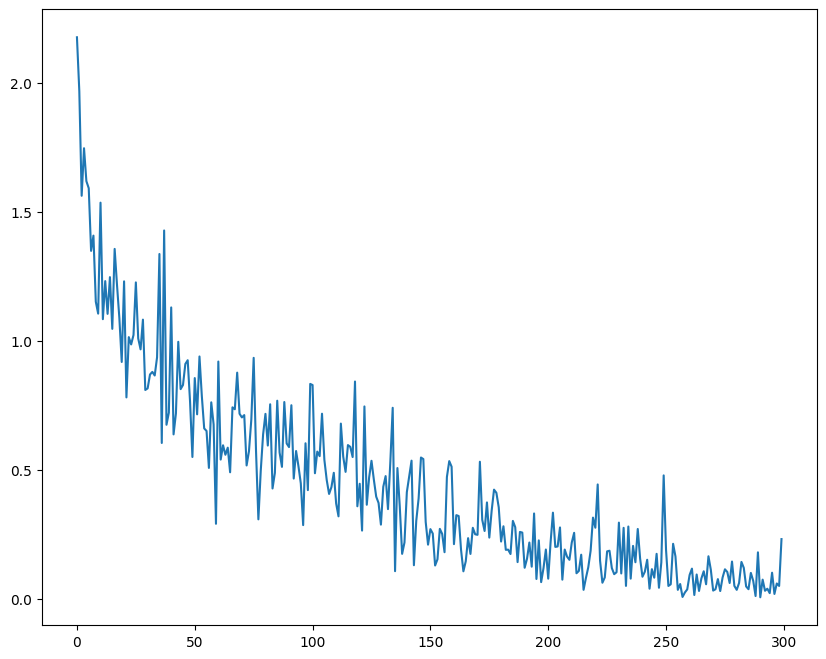

In [90]:
plt.figure(figsize=(10,8))
plt.plot(cnv_loss_log)

In [91]:
seed()

# Test the model
# In the test phase, don't need to compute gradients (for memory efficiency)
with torch.no_grad():
    model_cnn.eval()
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model_cnn(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print('Accuracy of the network on the test images: {} %'.format(100 * correct / total))

# Save the model checkpoint
torch.save(model.state_dict(), 'cnv_model.ckpt')

Accuracy of the network on the test images: 78.97 %
